In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob

from data import exclude

In [2]:
datadir = '../../data/lvk'

gwtc3_list = f'{datadir}/gwtc3.txt'
all_list = f'{datadir}/all.csv'

all_events = pd.read_csv(all_list, index_col=False)
gwtc3 = pd.read_csv(gwtc3_list, delimiter=' ', index_col=False)

events = []
snrs = []
fars = []
cats = []

for (event, snr, far, cat) in zip(gwtc3['commonName'].values, gwtc3['network_matched_filter_snr'].values, gwtc3['far'].values, gwtc3['catalog.shortName']):
    if len([ex for ex in exclude if ex in event]) == 0:
        events.append(str(event))
        snrs.append(snr)
        fars.append(far)
        cats.append(cat)

files = sorted([
    glob(f'/home/rp.o4/catalogs/GWTC-*/data-release/*{event}*_cosmo.h5')[0]
    for event in events
])

files4a = sorted(glob(
    '/home/rp.o4/catalogs/GWTC-4/GWTC4-Stable_Release-9/38214bd95_724/'
    'bbh_only/*.hdf5',
))

for file in files4a:
    e = 'GW' + file.split('/')[-1].split('GW')[-1][:13]

    if e in exclude:
        continue

    files.append(file)
    events.append(e)

    info = all_events.query(f'name == "{e}"')
    info = info.iloc[np.argmax(info['version'])]
    snrs.append(info['network_matched_filter_snr'])
    fars.append(info['far'])
    cats.append('GWCT-4')

In [3]:
snr_thresh = 15
far_thresh = 1e-5

found = []
for event, snr, far, catalog in zip(events, snrs, fars, cats):
    fi = ('GWTC-1' in catalog) & (snr >= snr_thresh)
    fi |= ('GWTC-1' not in catalog) & (far <= far_thresh)
    found.append(fi)
found = np.array(found)

In [5]:
samps = []

nobs = 0

for (path, event, is_found) in zip(files, events, found):

    if is_found:
        with h5py.File(path, 'r') as f:
            keys = list(set(f) - {'history', 'version'})

            for k in keys:
                if 'XPHM' in k:
                    samps.append(f[k]['posterior_samples']['cos_tilt_1'])
                    nobs += 1
                    break

In [6]:
nobs

63

In [7]:
samps = np.concatenate(samps)

In [9]:
samps_nrsur_or_mixed = []

for (path, event, is_found) in zip(files, events, found):

    if is_found:
        with h5py.File(path, 'r') as f:
            # GWTC-3
            if 'C01:Mixed' in f:
                data = f['C01:Mixed']['posterior_samples']
            # O4a
            elif 'C00:NRSur7dq4' in f:
                data = f['C00:NRSur7dq4']['posterior_samples']

            elif 'C00:Mixed' in f:
                data = f['C00:Mixed']['posterior_samples']

            samps_nrsur_or_mixed.append(data['cos_tilt_1'])

In [10]:
samps_nrsur_or_mixed = np.concatenate(samps_nrsur_or_mixed)

In [13]:
import h5ify
xphm = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm.h5')

In [20]:
xphm['posteriors']['cos_tilt_1'].flatten()

array([-0.18503333, -0.7216659 , -0.25418833, ...,  0.41904682,
       -0.96966587, -0.13916395], shape=(1057689,))

In [34]:
from data import get_data

_, xphm, _ = get_data(snr_thresh=15, far_thresh=1e-5, prefer_xphm=True)

loading posteriors from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm.h5


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

In [32]:
xphm['cos_tilt_1'].flatten()

array([-0.18503333, -0.7216659 , -0.25418833, ...,  0.62660547,
        0.4851114 , -0.05812241], shape=(435519,))

In [33]:
samps

array([-0.33584997, -0.26697035, -0.71393285, ..., -0.21131756,
        0.19141479, -0.10341951], shape=(3157691,))

Text(0.5, 0, '$\\cos \\tau_1$')

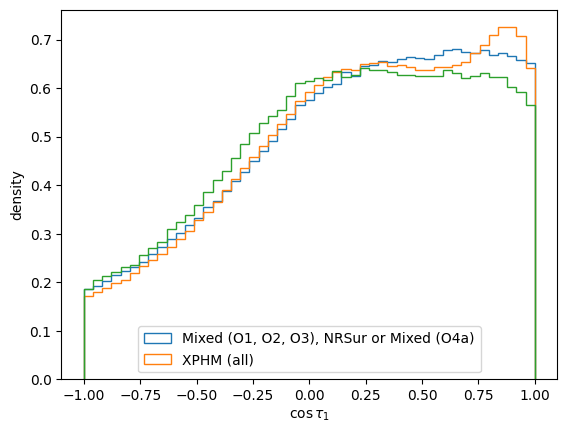

In [29]:
fig, ax = plt.subplots()
ax.hist(samps_nrsur_or_mixed, histtype='step', bins=np.linspace(-1, 1, 50), density=True, label='Mixed (O1, O2, O3), NRSur or Mixed (O4a)');
ax.hist(samps, histtype='step', bins=np.linspace(-1, 1, 50), density=True, label='XPHM (all)');
ax.hist(
    xphm['cos_tilt_1'].flatten(),
    histtype='step',
    bins=np.linspace(-1, 1, 50),
    density=True
)

ax.legend();

ax.set_ylabel('density')
ax.set_xlabel(r'$\cos \tau_1$')

#fig.savefig('../../data/inference/cuts/wvfs/concat.png')

/local/noah.wolfe/ipykernel_934284/1783447322.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


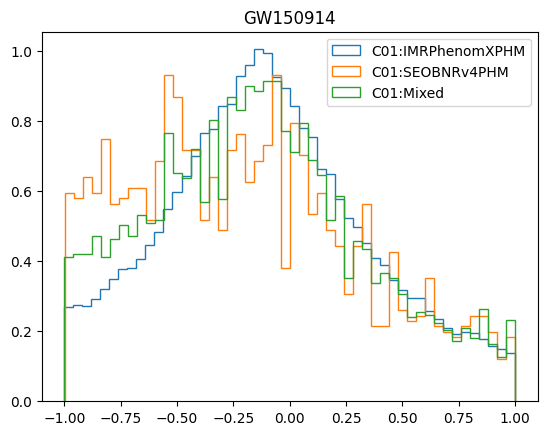

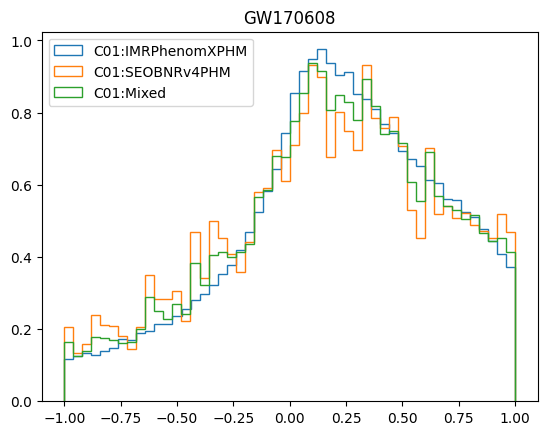

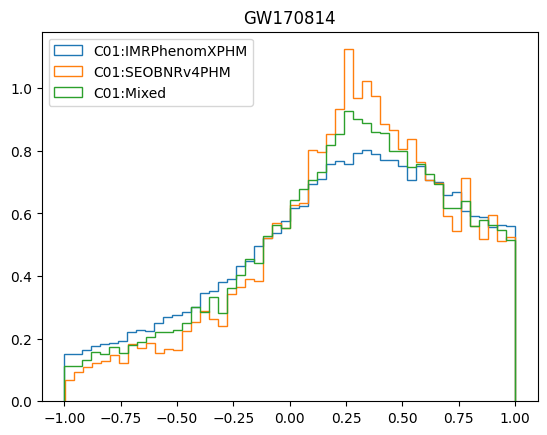

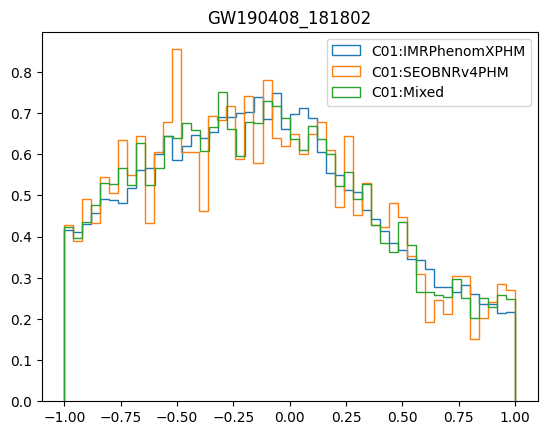

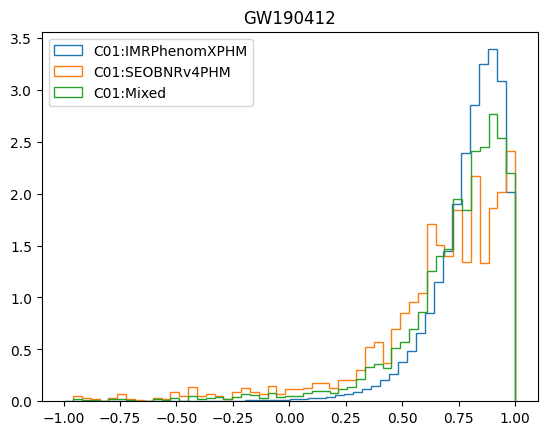

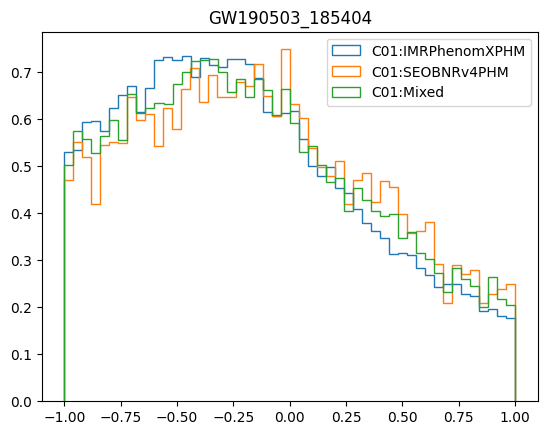

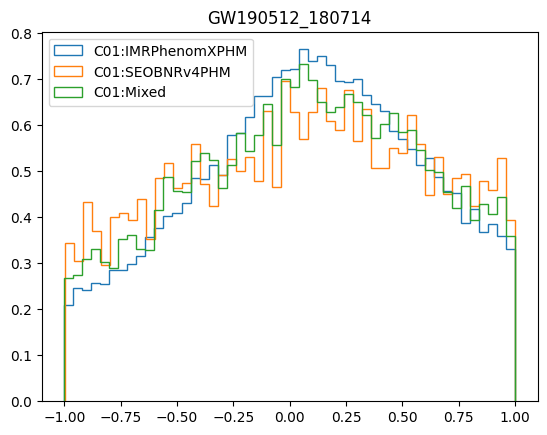

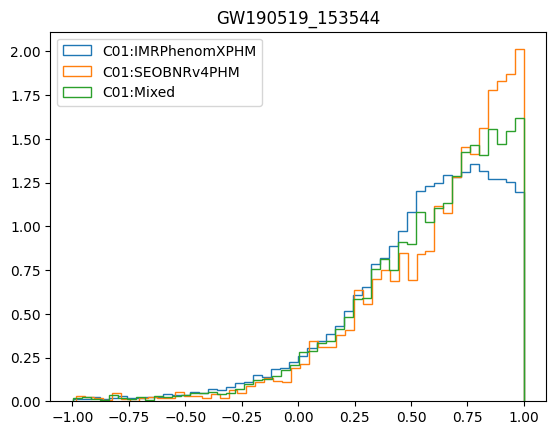

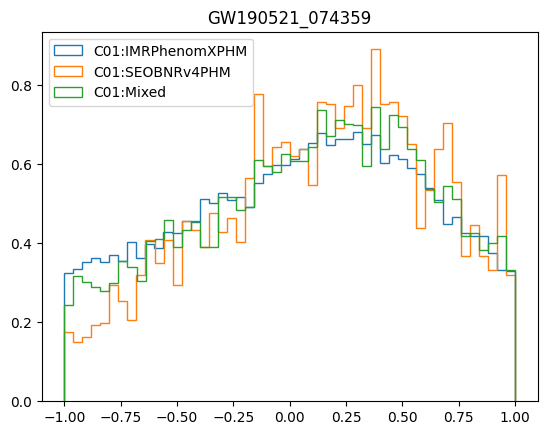

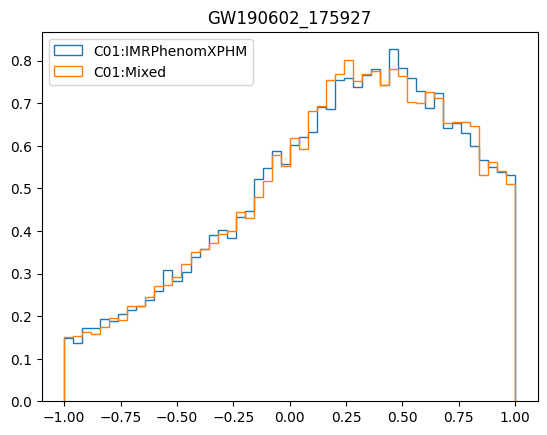

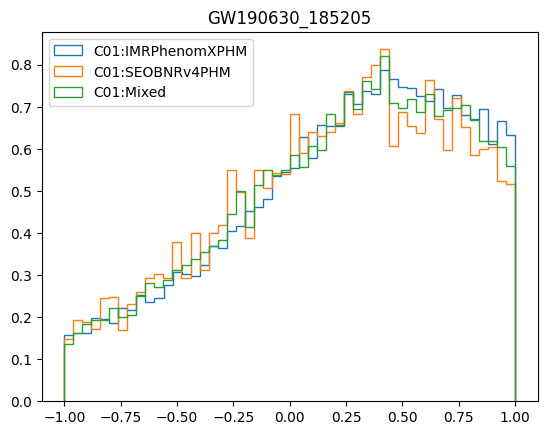

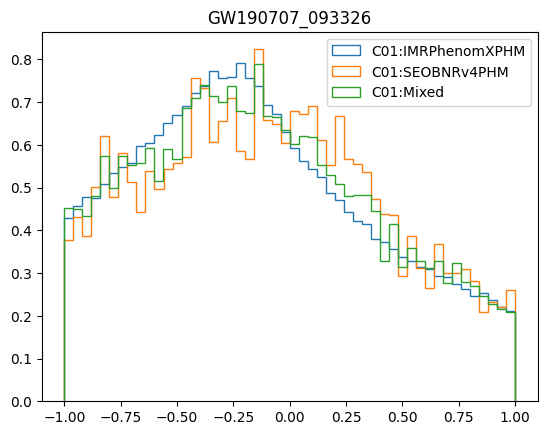

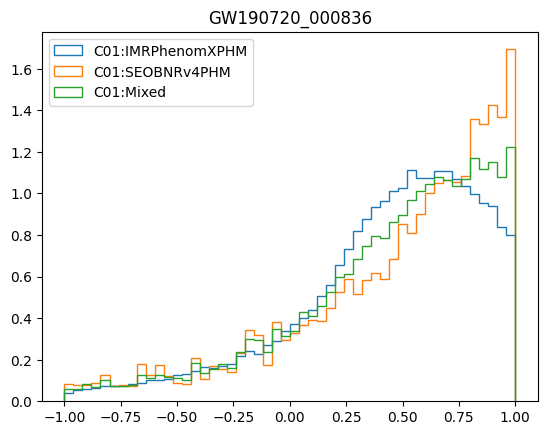

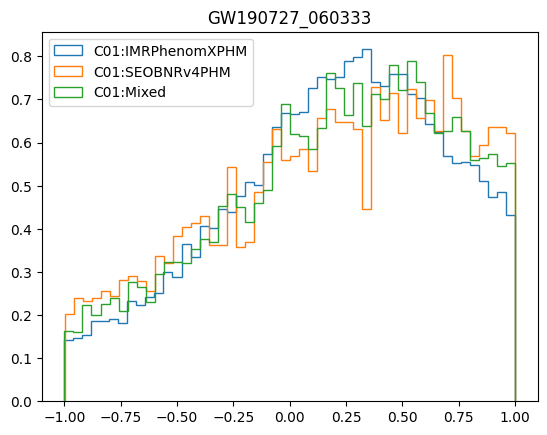

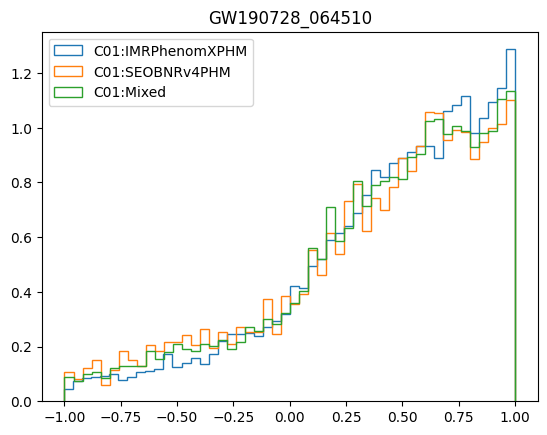

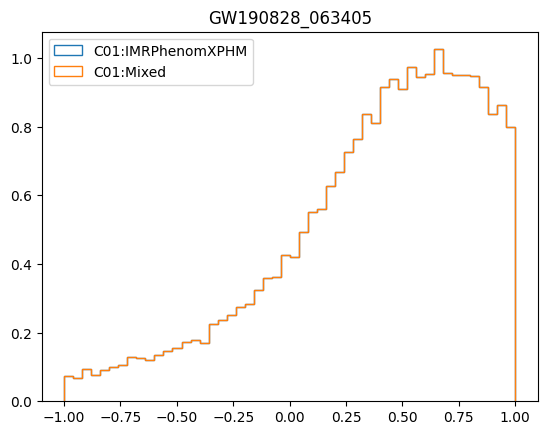

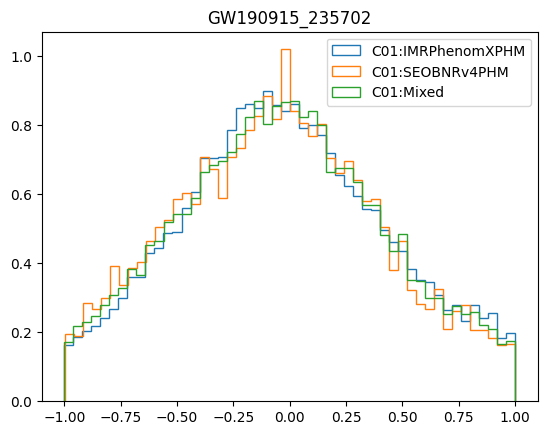

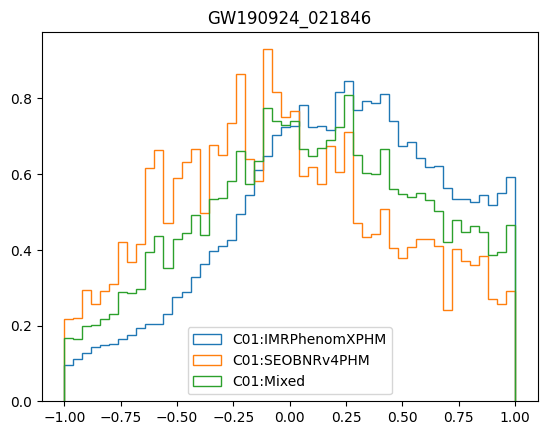

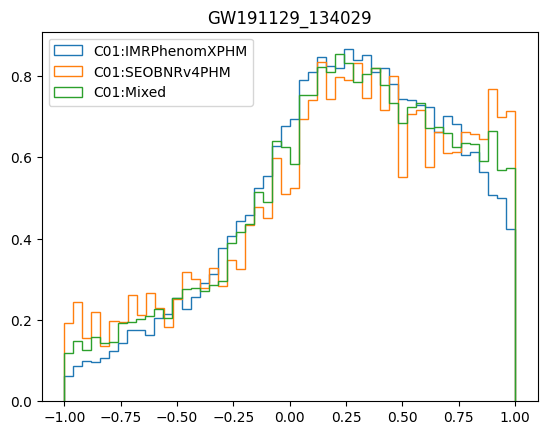

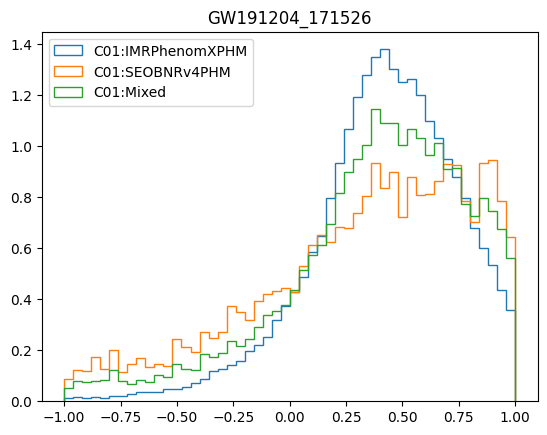

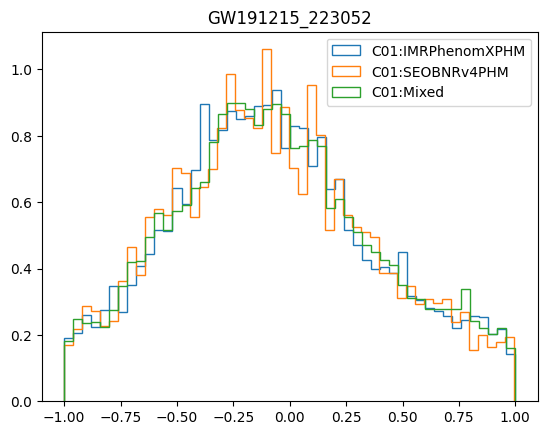

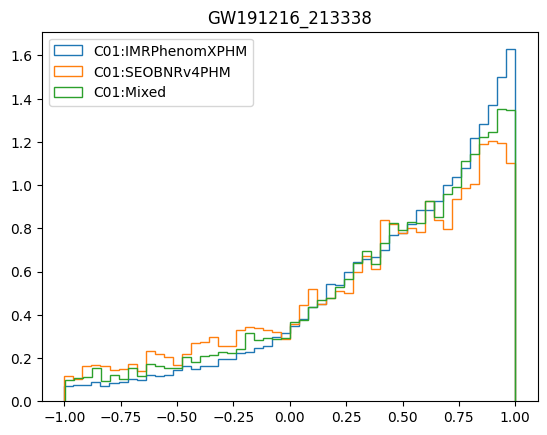

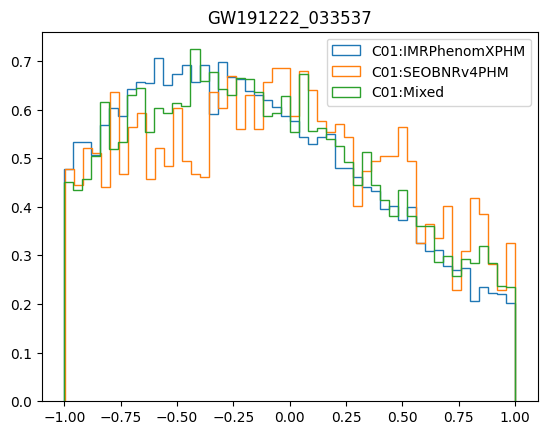

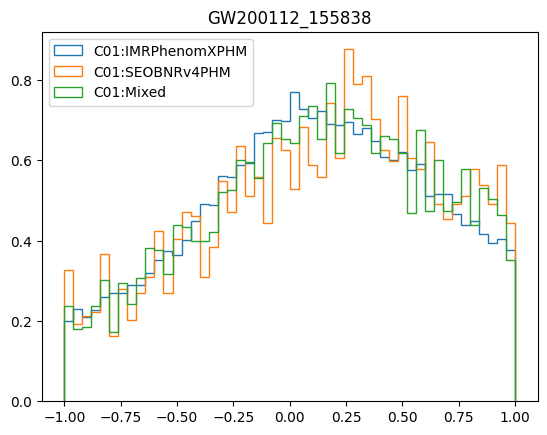

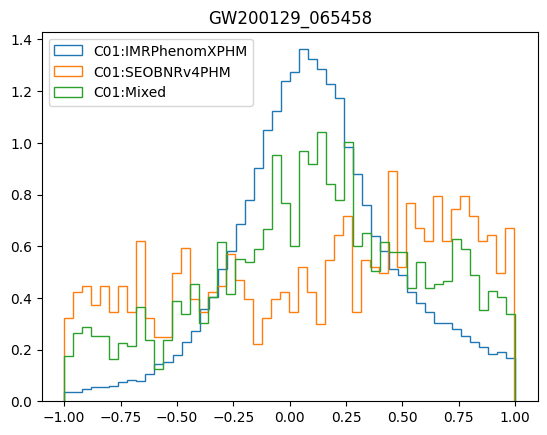

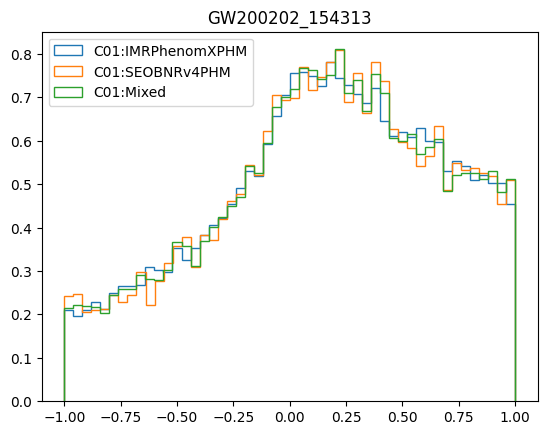

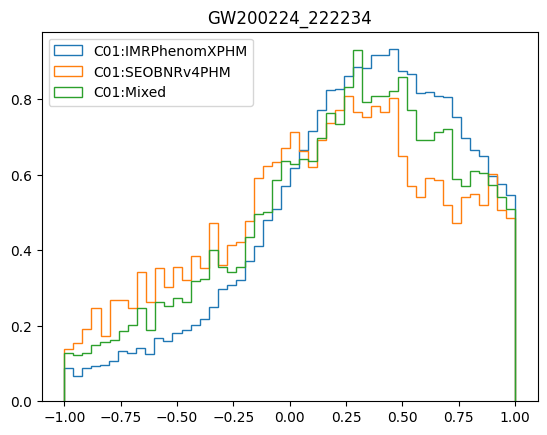

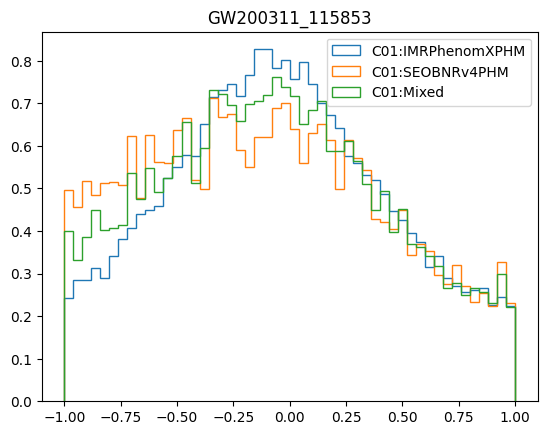

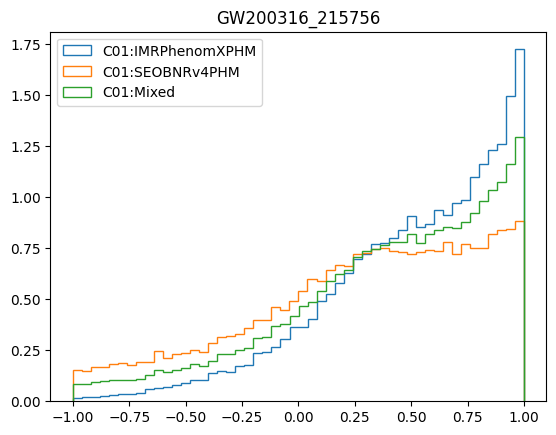

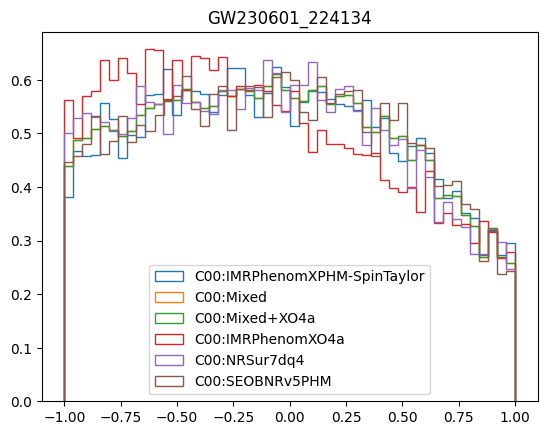

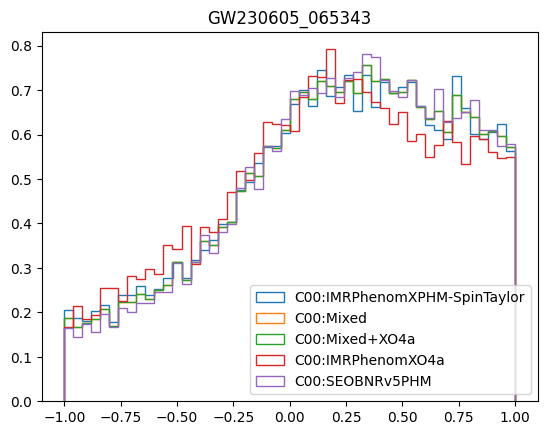

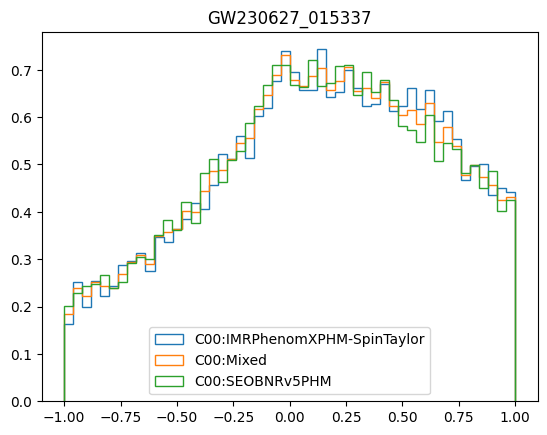

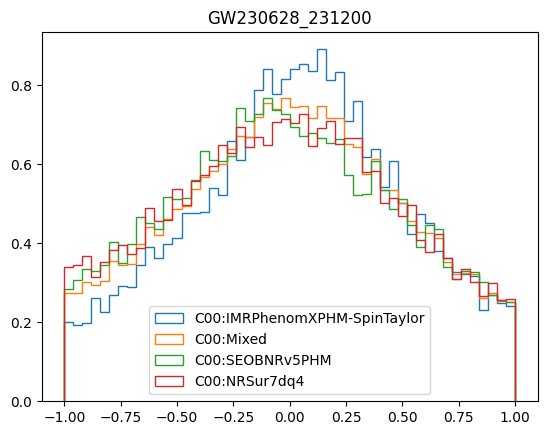

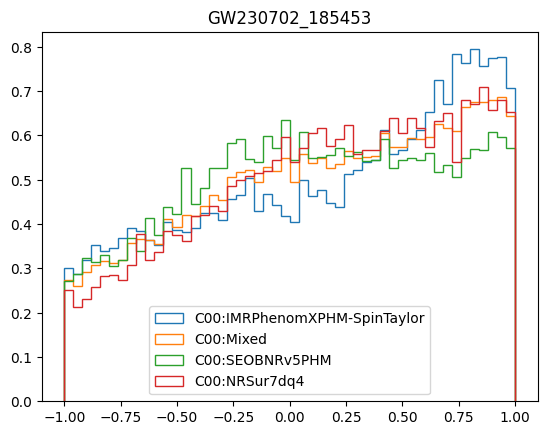

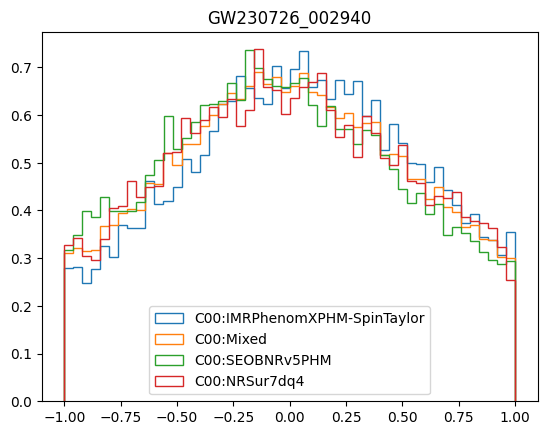

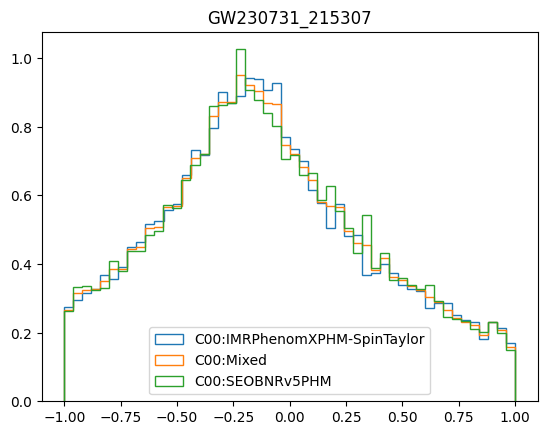

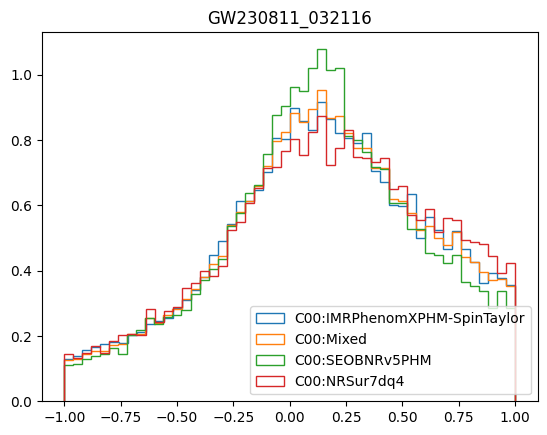

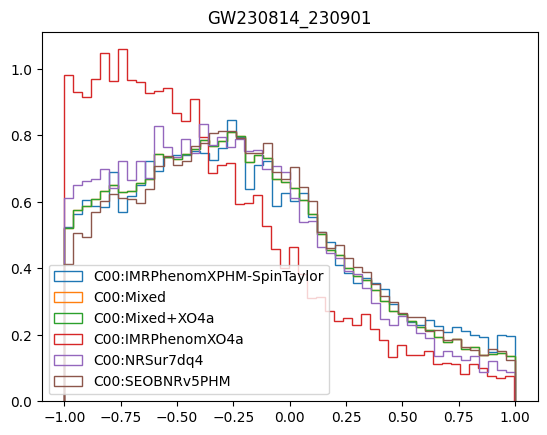

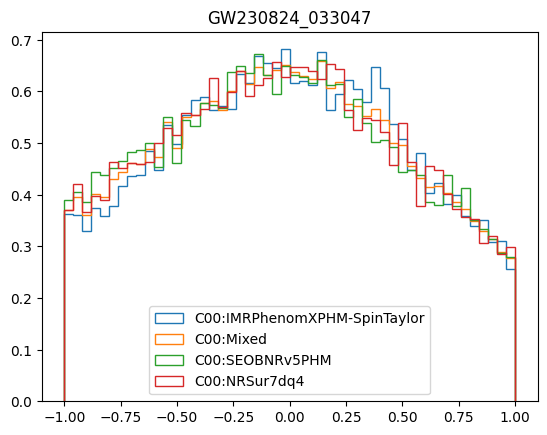

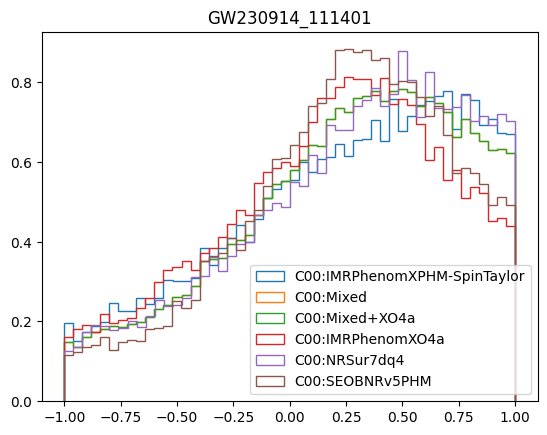

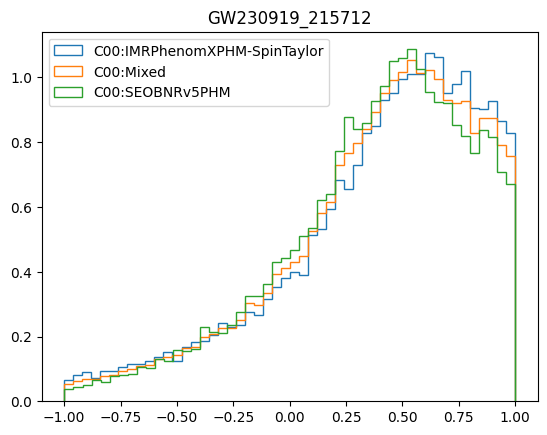

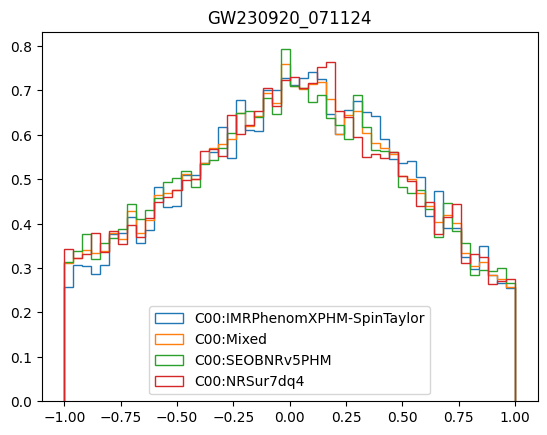

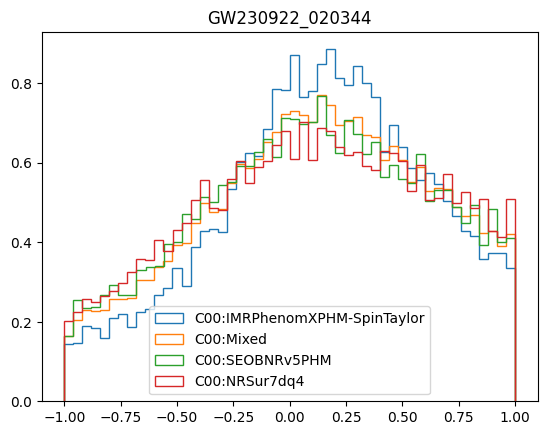

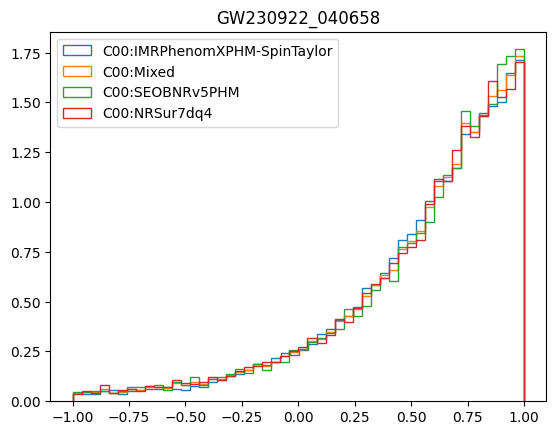

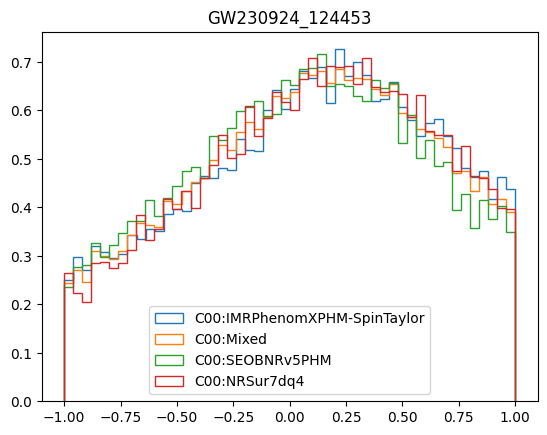

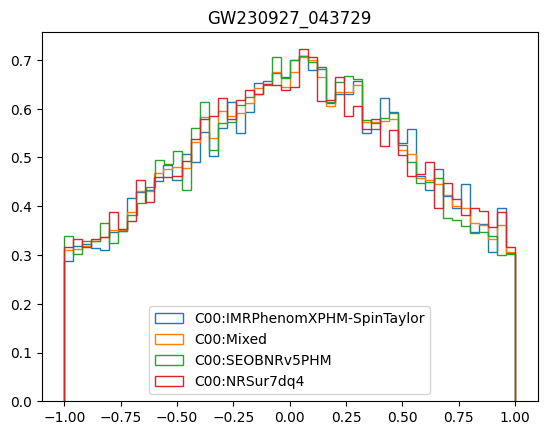

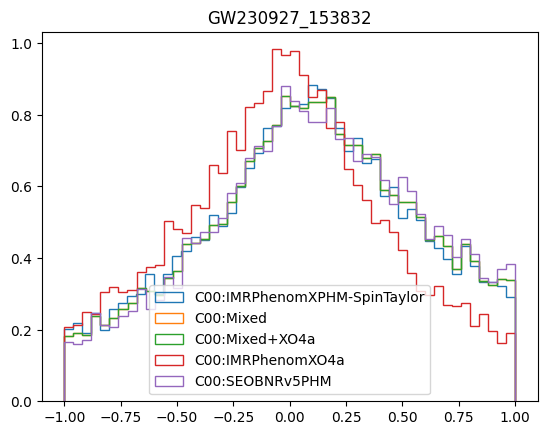

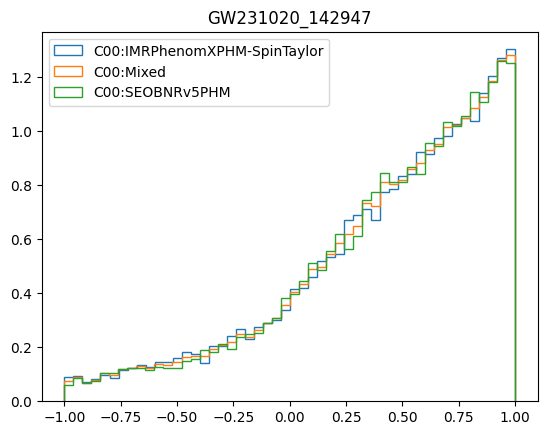

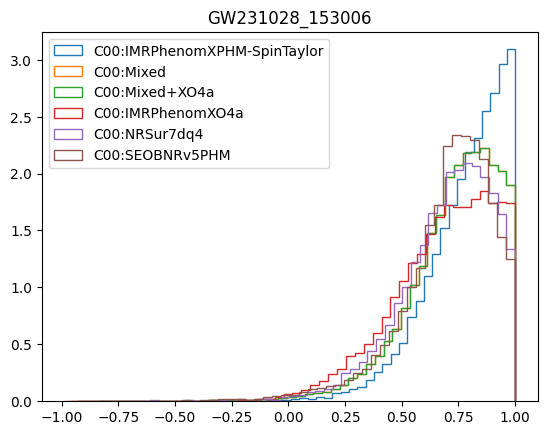

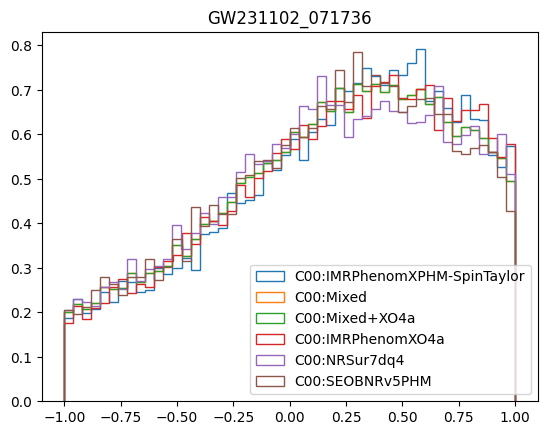

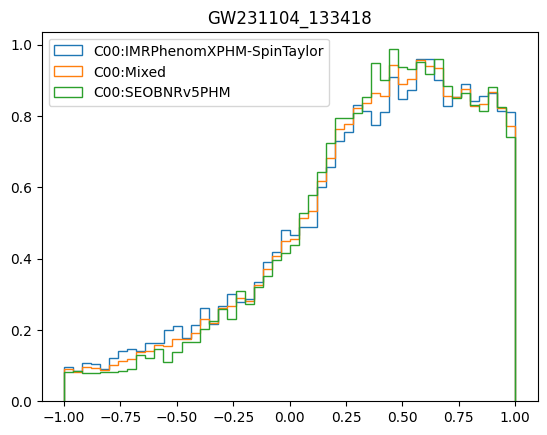

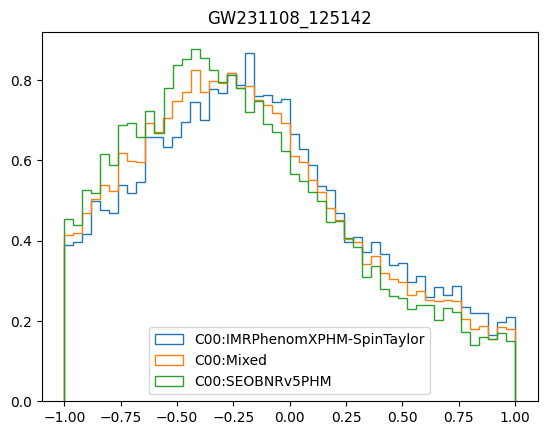

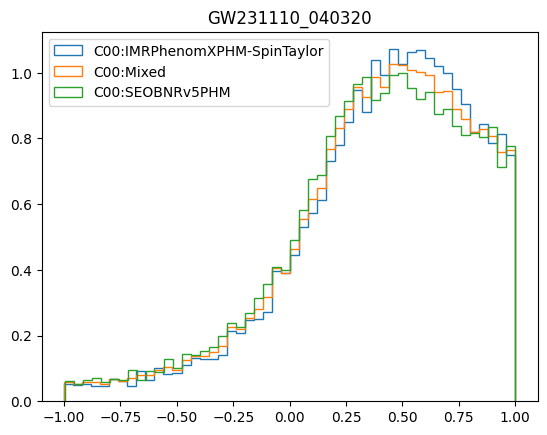

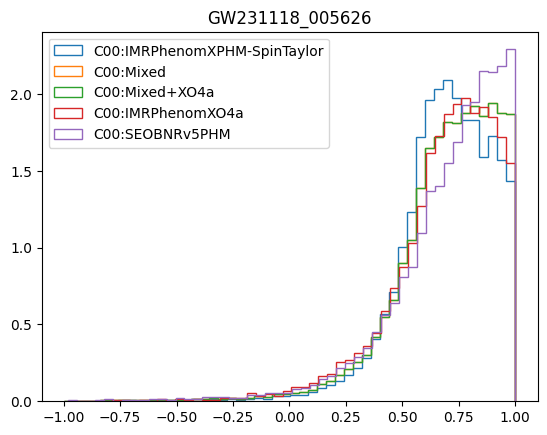

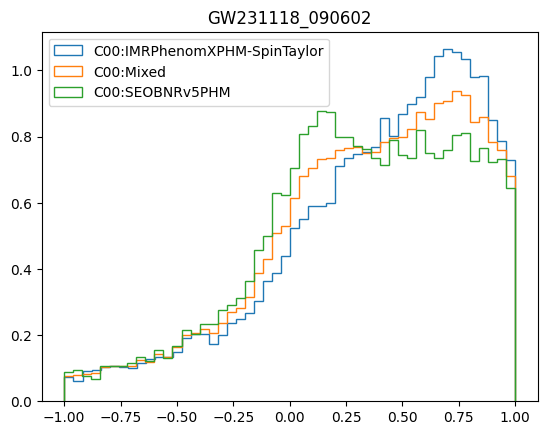

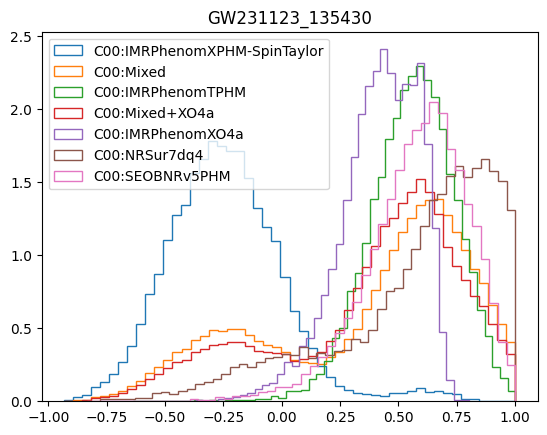

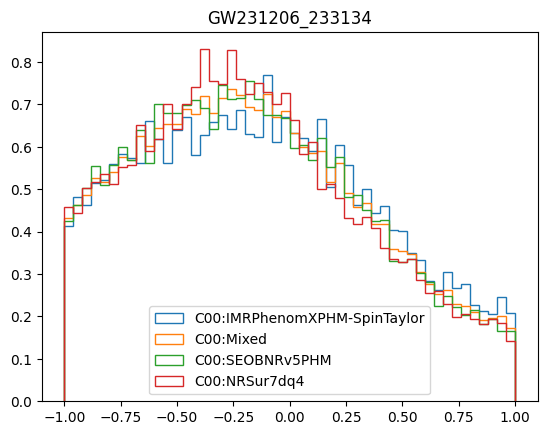

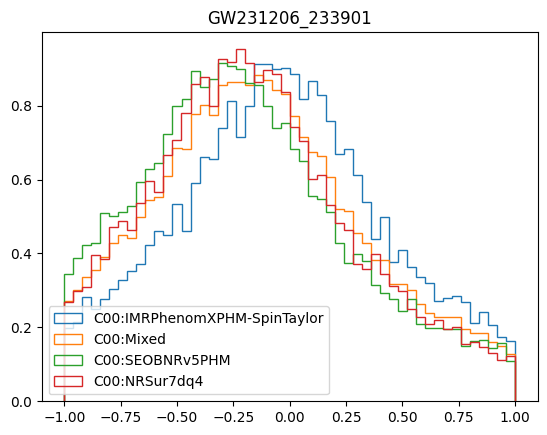

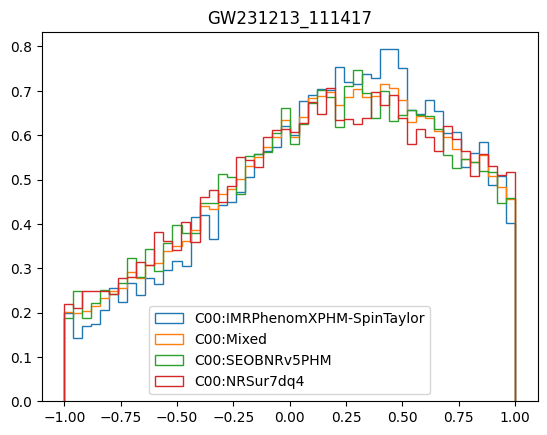

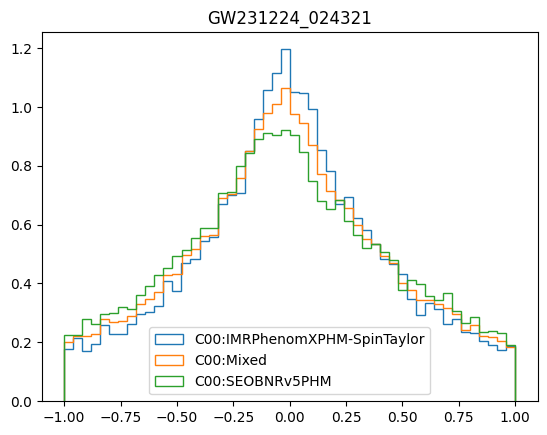

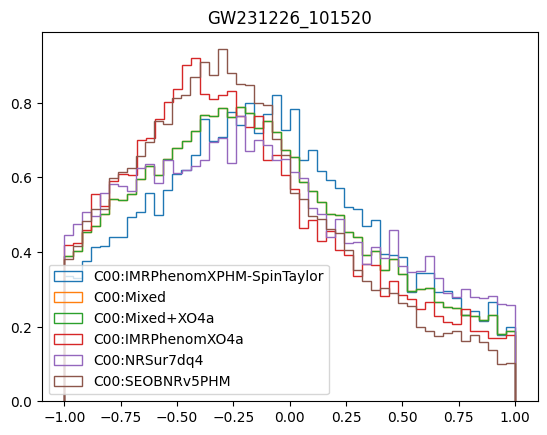

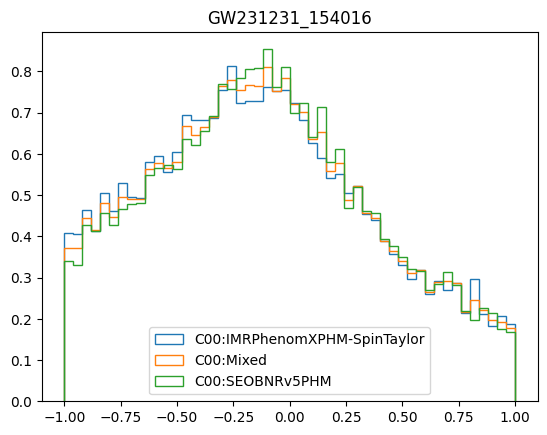

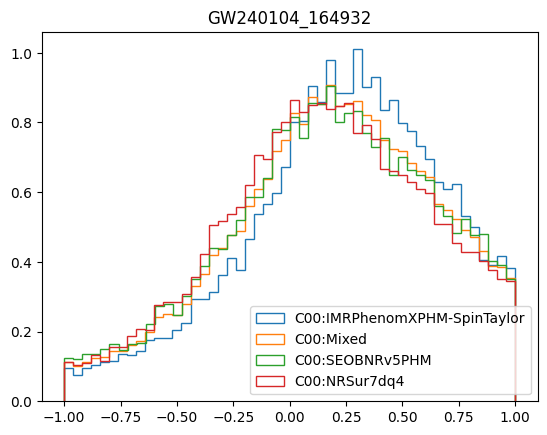

In [14]:
for (path, event, is_found) in zip(files, events, found):

    if is_found:
        with h5py.File(path, 'r') as f:
            keys = list(set(f) - {'history', 'version'})

            if len(keys) > 1:

                fig, ax = plt.subplots()

                for k in keys:
                    data = f[k]['posterior_samples']
                    ax.hist(data['cos_tilt_1'], histtype='step', bins=50, density=True, label=k)

                ax.legend()
                ax.set_title(event)
                fig.savefig(f'../../data/inference/cuts/wvfs/{event}.png')